In [ ]:
from google.colab import files
uploaded = files.upload()


Saving customer_journey.csv to customer_journey.csv


First 5 Rows
   SessionID     UserID            Timestamp      PageType DeviceType  \
0  session_0  user_2223  2025-01-20 22:53:34          home    Desktop   
1  session_1  user_2192  2025-02-26 12:57:10          home     Tablet   
2  session_1  user_2192  2025-02-26 12:59:11  product_page     Tablet   
3  session_2  user_1708  2025-06-24 15:40:46          home     Mobile   
4  session_3  user_2976  2025-06-11 07:21:02          home     Tablet   

   Country ReferralSource  TimeOnPage_seconds  ItemsInCart  Purchased  
0    India   Social Media                  55            0          0  
1  Germany          Email                  99            0          0  
2  Germany          Email                 121            0          0  
3    India         Google                 160            0          0  
4       UK         Google                 113            0          0  

Dataset Shape
(12719, 10)

Columns
Index(['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country',


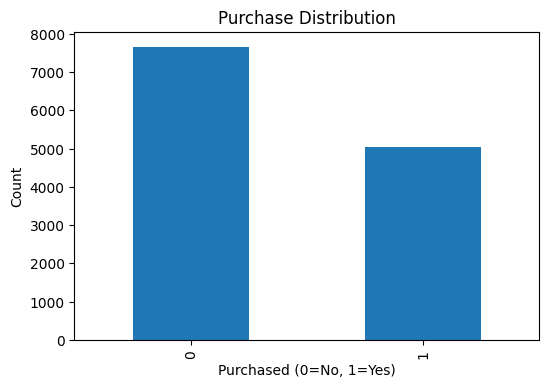

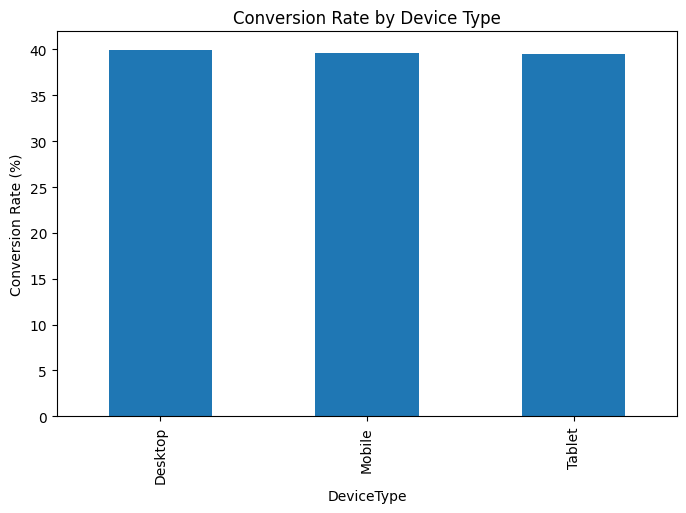

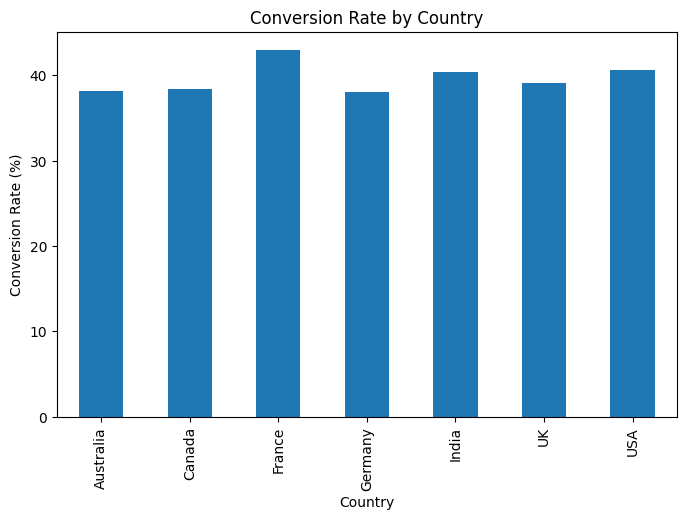

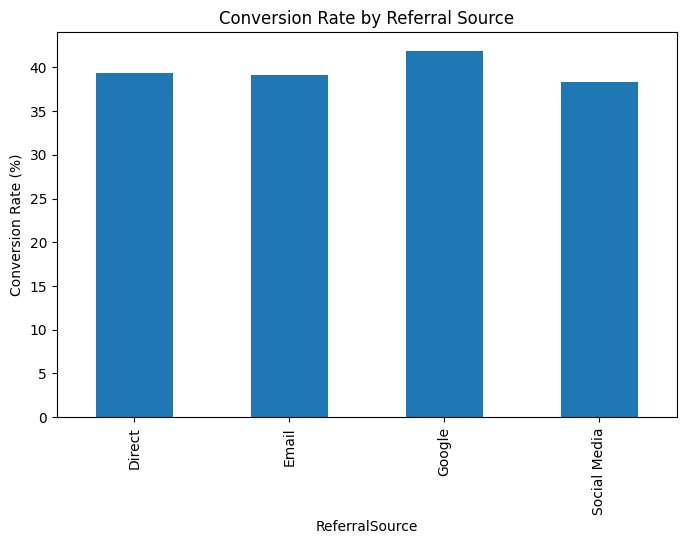

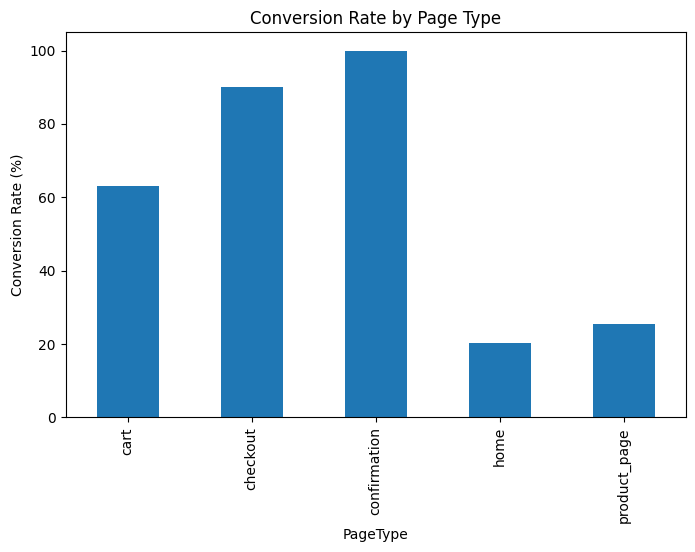

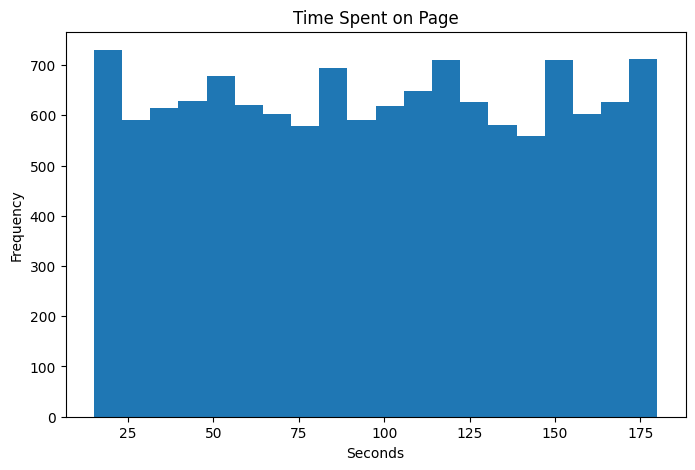

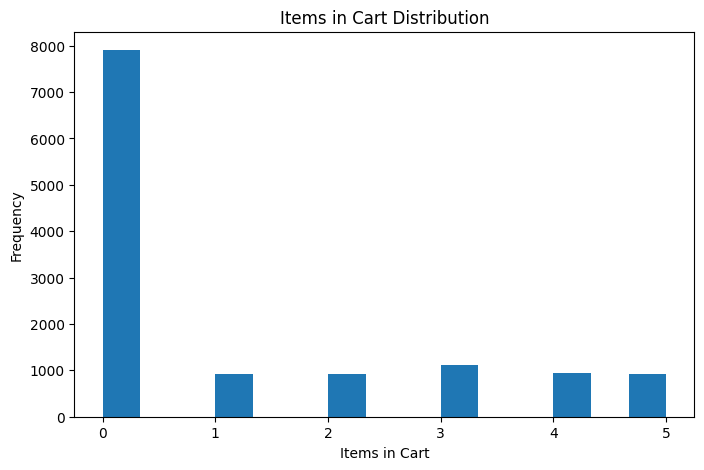

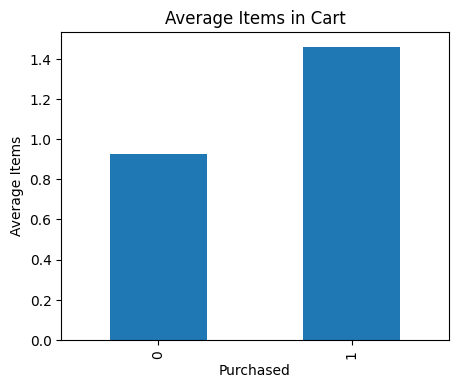

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("customer_journey.csv")

# Basic Exploration
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Overall Conversion Rate
conversion_rate = df['Purchased'].mean() * 100
print(f"\nOverall Conversion Rate: {conversion_rate:.2f}%")

# Conversion vs Non-Conversion
plt.figure(figsize=(6,4))
df['Purchased'].value_counts().plot(kind='bar')
plt.title("Purchase Distribution")
plt.xlabel("Purchased (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# Device Type Analysis
plt.figure(figsize=(8,5))
device_conversion = df.groupby('DeviceType')['Purchased'].mean() * 100
device_conversion.plot(kind='bar')
plt.title("Conversion Rate by Device Type")
plt.ylabel("Conversion Rate (%)")
plt.show()

# Country Analysis
plt.figure(figsize=(8,5))
country_conversion = df.groupby('Country')['Purchased'].mean() * 100
country_conversion.plot(kind='bar')
plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate (%)")
plt.show()

# Referral Source Analysis
plt.figure(figsize=(8,5))
referral_conversion = df.groupby('ReferralSource')['Purchased'].mean() * 100
referral_conversion.plot(kind='bar')
plt.title("Conversion Rate by Referral Source")
plt.ylabel("Conversion Rate (%)")
plt.show()

# Page Type Analysis
plt.figure(figsize=(8,5))
page_conversion = df.groupby('PageType')['Purchased'].mean() * 100
page_conversion.plot(kind='bar')
plt.title("Conversion Rate by Page Type")
plt.ylabel("Conversion Rate (%)")
plt.show()

# Time on Page Distribution
plt.figure(figsize=(8,5))
plt.hist(df['TimeOnPage_seconds'], bins=20)
plt.title("Time Spent on Page")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

# Items in Cart Distribution
plt.figure(figsize=(8,5))
plt.hist(df['ItemsInCart'], bins=15)
plt.title("Items in Cart Distribution")
plt.xlabel("Items in Cart")
plt.ylabel("Frequency")
plt.show()

# Average Cart Size for Purchasers vs Non-Purchasers
cart_data = df.groupby('Purchased')['ItemsInCart'].mean()

plt.figure(figsize=(5,4))
cart_data.plot(kind='bar')
plt.title("Average Items in Cart")
plt.xlabel("Purchased")
plt.ylabel("Average Items")
plt.show()